In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name:
    print('GPU found:', device_name)
else:
    print("No GPU found, using CPU.")

GPU found: /device:GPU:0


In [ ]:
!nvidia-smi

Tue Oct 21 05:21:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             28W /   70W |     102MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Import Libraries
# ==========================
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

### Cell EM_FfKqNKsA9: GPU Device Check

This cell checks for the availability of a GPU and prints its name if found, otherwise it indicates that the CPU is being used. This is important for deep learning tasks as GPUs significantly accelerate computation.

*   `import tensorflow as tf`: Imports the TensorFlow library, which is an open-source machine learning framework.
*   `device_name = tf.test.gpu_device_name()`: Calls a TensorFlow function to get the name of the GPU device if one is available.
*   `if device_name:`: Checks if a GPU device name was returned (meaning a GPU was found).
*   `print('GPU found:', device_name)`: If a GPU is found, prints its name.
*   `else:`: If no GPU is found.
*   `print("No GPU found, using CPU.")`: Prints a message indicating that the CPU will be used instead.

### Cell 3yorcaj9LHF3: NVIDIA GPU System Information

This cell executes a shell command to display detailed information about the NVIDIA GPU(s) available on the system. This provides insights into GPU memory usage, driver version, CUDA version, temperature, power consumption, and running processes.

*   `!nvidia-smi`: Executes the `nvidia-smi` command-line utility. The `!` prefix allows running shell commands directly within a Colab notebook.

### Cell bMvZP_3jLdKk: Import Libraries

This cell imports all the necessary Python libraries for building, training, and evaluating a deep learning model for image classification.

*   `import time`: Imports the `time` module, often used for time-related tasks, though not directly used in the current model training loop.
*   `import numpy as np`: Imports the NumPy library, essential for numerical operations, especially with arrays and matrices.
*   `import matplotlib.pyplot as plt`: Imports Matplotlib's pyplot module, used for creating static, interactive, and animated visualizations in Python.
*   `import seaborn as sns`: Imports Seaborn, a data visualization library based on Matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.
*   `from sklearn.metrics import confusion_matrix, classification_report`: Imports specific metrics from scikit-learn for model evaluation: `confusion_matrix` to assess classification performance and `classification_report` for a summary of precision, recall, and f1-score.
*   `import tensorflow as tf`: Imports the TensorFlow library.
*   `from tensorflow.keras.preprocessing import image_dataset_from_directory`: Imports a utility function from Keras (part of TensorFlow) to easily load image data from directories, automatically inferring labels from subfolder names.
*   `from tensorflow.keras.applications import DenseNet121`: Imports the `DenseNet121` pre-trained convolutional neural network model, which is a powerful architecture for image feature extraction.
*   `from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization`: Imports various layer types from Keras for building the neural network:
    *   `Dense`: A regular densely-connected neural network layer.
    *   `GlobalAveragePooling2D`: Performs global average pooling on the spatial dimensions of its input, often used to reduce the number of parameters and prevent overfitting.
    *   `Dropout`: Randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting.
    *   `BatchNormalization`: Normalizes the activations of the previous layer at each batch, i.e. applies a transformation that maintains the mean output close to 0 and the output standard deviation close to 1.
*   `from tensorflow.keras.models import Model`: Imports the `Model` class from Keras, used to create models by specifying their inputs and outputs.
*   `from tensorflow.keras.optimizers import Adam`: Imports the Adam optimizer, a popular optimization algorithm used for training neural networks.
*   `from tensorflow.keras.regularizers import l2`: Imports the L2 regularization (weight decay) from Keras, used to prevent overfitting by adding a penalty to the loss function that is proportional to the square of the magnitude of the weights.

### Cell sRKT0_WcLn0c: Mount Google Drive

This cell mounts your Google Drive to the Colab environment, allowing the notebook to access files stored in your Drive, such as the image datasets.

*   `from google.colab import drive`: Imports the `drive` module specifically designed for Google Colab.
*   `drive.mount('/content/drive')`: Executes the function to mount Google Drive. This will typically prompt you to authenticate your Google account in a pop-up window.

### Cell YmJ5CNKsLqHK: Define Data Paths and Parameters

This cell defines the paths to the training and testing (validation) image datasets, along with key parameters for image processing and model training.

*   `train_dir = "/content/drive/MyDrive/XR_ELBOW/Train"`: Sets the variable `train_dir` to the file path of the training dataset, located within the mounted Google Drive.
*   `test_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"`: Sets the variable `test_dir` to the file path of the validation (or test) dataset.
*   `IMG_SIZE = (224, 224)`: Defines the target image size (height, width) to which all input images will be resized. `224x224` is a common input size for many pre-trained convolutional neural networks like DenseNet.
*   `BATCH_SIZE = 32`: Defines the number of samples that will be processed in one go during training. Using batches helps optimize memory usage and training speed.

### Cell CLEArNyDLKX: Load Training Dataset

This cell uses Keras's `image_dataset_from_directory` utility to load the training images into a TensorFlow `Dataset` object, which is optimized for deep learning workflows.

*   `train_ds_raw = image_dataset_from_directory(...)`: Creates a `tf.data.Dataset` from image files in the `train_dir`.
    *   `train_dir`: Specifies the root directory containing the image data. Subdirectories within `train_dir` are treated as distinct classes.
    *   `image_size=IMG_SIZE`: Resizes all images to the `IMG_SIZE` (224x224 pixels).
    *   `batch_size=BATCH_SIZE`: Groups images into batches of `BATCH_SIZE` (32) for training.
    *   `shuffle=True`: Shuffles the order of the images in the dataset, which is crucial for good training performance and to prevent the model from learning the order of samples.

### Cell hNDrn5i4MB3p: Load Validation Dataset

Similar to the training dataset, this cell loads the validation images into a TensorFlow `Dataset` object.

*   `val_ds_raw = image_dataset_from_directory(...)`: Creates a `tf.data.Dataset` from image files in the `test_dir`.
    *   `test_dir`: Specifies the root directory for validation images.
    *   `image_size=IMG_SIZE`: Resizes images to `IMG_SIZE` (224x224 pixels).
    *   `batch_size=BATCH_SIZE`: Groups images into batches of `BATCH_SIZE` (32).
    *   `shuffle=False`: Does **not** shuffle the validation data. It's generally not necessary or sometimes undesirable to shuffle validation/test sets, as the order might be used for consistency in evaluation.

### Cell bBERwzHrMJcx: Extract Class Information

This cell retrieves the names of the classes (labels) from the loaded training dataset and calculates the total number of classes. This information is critical for configuring the output layer of the neural network.

*   `class_names = train_ds_raw.class_names`: Accesses the `class_names` attribute of the `train_ds_raw` dataset, which contains a list of directory names that `image_dataset_from_directory` inferred as class labels.
*   `num_classes = len(class_names)`: Calculates the number of unique classes by getting the length of the `class_names` list.
*   `print("Number of classes:", num_classes)`: Prints the total count of classes.
*   `print("Class names:", class_names)`: Prints the names of the identified classes (e.g., 'negative', 'positive').

### Cell UypxoxmPMNDB: Optimize Dataset Performance with Prefetching

This cell applies prefetching to the training and validation datasets to improve I/O performance during model training. Prefetching overlaps data preprocessing and model execution, preventing the GPU (or CPU) from waiting for data.

*   `AUTOTUNE = tf.data.AUTOTUNE`: `AUTOTUNE` is a special value that tells the TensorFlow runtime to dynamically tune the number of elements to prefetch at runtime.
*   `train_ds = train_ds_raw.prefetch(buffer_size=AUTOTUNE)`: Applies prefetching to the raw training dataset. This means that while the model is training on the current batch, the next batch is being loaded and preprocessed in the background.
*   `val_ds = val_ds_raw.prefetch(buffer_size=AUTOTUNE)`: Applies the same prefetching optimization to the raw validation dataset.

### Cell gtTqLK09MRZx: Build the Transfer Learning Model

This cell constructs the neural network model using a pre-trained DenseNet121 as the base feature extractor and adds custom layers on top for classification. This is a common practice in transfer learning.

*   `base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))`: Initializes the DenseNet121 model.
    *   `weights='imagenet'`: Loads pre-trained weights from the ImageNet dataset, which helps the model learn powerful general-purpose image features.
    *   `include_top=False`: Excludes the original classification layer (the "top") of DenseNet121, as we will add our own custom classifier for our specific problem.
    *   `input_shape=(224, 224, 3)`: Defines the expected input shape for the images (height, width, color channels).
*   `for layer in base_model.layers: layer.trainable = False`: This loop iterates through all layers of the `base_model` and sets their `trainable` attribute to `False`. This "freezes" the pre-trained layers, meaning their weights will not be updated during the initial training phase. This preserves the learned features from ImageNet.
*   `x = base_model.output`: Gets the output tensor from the frozen `base_model`. This will be the input to our custom classification layers.
*   `x = GlobalAveragePooling2D()(x)`: Adds a `GlobalAveragePooling2D` layer. This layer takes the average of each feature map, drastically reducing the number of parameters and making the model more robust to spatial translations.
*   `x = BatchNormalization()(x)`: Adds a `BatchNormalization` layer. This normalizes the activations from the previous layer, which helps in stabilizing and accelerating the training process.
*   `x = Dropout(0.5)(x)`: Adds a `Dropout` layer with a rate of 0.5. During training, 50% of the neurons' outputs are randomly set to zero, which helps prevent overfitting.
*   `x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)`: Adds a `Dense` (fully connected) layer with 256 units and a ReLU activation function. `kernel_regularizer=l2(0.001)` applies L2 regularization to the weights of this layer, further combating overfitting.
*   `x = BatchNormalization()(x)`: Another `BatchNormalization` layer for the activations from the previous dense layer.
*   `x = Dropout(0.4)(x)`: Another `Dropout` layer, this time with a 40% dropout rate.
*   `outputs = Dense(num_classes, activation='softmax')(x)`: This is the final output `Dense` layer of the model.
    *   `num_classes`: The number of units in this layer matches the number of classes we are trying to predict.
    *   `activation='softmax'`: The softmax activation function is used for multi-class classification, converting the raw outputs into probabilities that sum to 1 across all classes.
*   `model = Model(inputs=base_model.input, outputs=outputs)`: Creates the final Keras `Model` by specifying its input (from `base_model.input`) and its output (from our custom `outputs` layer).

### Cell F5_fQ3h8M4OT: Compile the Model

This cell configures the model for training by specifying the optimizer, loss function, and metrics to monitor.

*   `model.compile(...)`: Configures the model for training.
    *   `optimizer=Adam(learning_rate=1e-4)`: Sets the optimizer to Adam, with an initial learning rate of `0.0001`. Adam is an adaptive learning rate optimization algorithm known for its efficiency.
    *   `loss='sparse_categorical_crossentropy'`: Specifies the loss function. `sparse_categorical_crossentropy` is suitable for classification problems where labels are integers (not one-hot encoded) and there are more than two classes (or when using `softmax` for binary classification).
    *   `metrics=['accuracy']`: Defines the metrics to be evaluated by the model during training and testing. Here, `accuracy` will be monitored.

### Cell _brJsfttNlDa: Train the Model (Phase 1: Feature Extraction)

This cell initiates the training process for the model. In this phase, only the newly added classification layers are trained, while the base DenseNet121 layers remain frozen.

*   `EPOCHS = 50`: Sets the total number of training epochs for this phase to 50. An epoch is one complete pass through the entire training dataset.
*   `history = model.fit(...)`: Starts the training process.
    *   `train_ds`: The training dataset used to update the model's weights.
    *   `validation_data=val_ds`: The validation dataset used to monitor the model's performance on unseen data after each epoch. This helps in detecting overfitting.
    *   `epochs=EPOCHS`: Specifies the number of epochs to train for.

The `history` object returned by `model.fit()` contains a record of training loss values and metrics (like accuracy) at successive epochs, for both the training and validation sets.

### Cell 400WspvyNvge: Prepare for Fine-Tuning

After the initial training phase, this cell unfreezes some of the `base_model` layers and recompiles the model with a lower learning rate. This step, known as fine-tuning, allows the model to adapt the pre-trained features more specifically to the new dataset.

*   `for layer in base_model.layers[-50:]: layer.trainable = True`: This loop iterates through the last 50 layers of the `base_model` and sets their `trainable` attribute to `True`. This unfreezes these layers, allowing their weights to be updated during the next training phase.
*   `model.compile(...)`: The model is recompiled. It's crucial to recompile the model after changing the `trainable` attribute of any layers for the changes to take effect.
    *   `optimizer=Adam(learning_rate=1e-5)`: The Adam optimizer is used again, but with a significantly **lower learning rate** (`0.00001`). A smaller learning rate is essential during fine-tuning to avoid drastically altering the pre-trained weights and potentially ruining the learned features.
    *   `loss='sparse_categorical_crossentropy'`: The loss function remains the same.
    *   `metrics=['accuracy']`: The metrics also remain the same.

### Cell ZfjrTE2CYRsG: Fine-Tune the Model (Phase 2: Fine-tuning)

This cell continues the training process, now with some of the `base_model` layers unfrozen, allowing for more nuanced adjustments to the model's weights.

*   `fine_tune_epochs = 25`: Defines the number of epochs for this fine-tuning phase as 25.
*   `total_epochs = EPOCHS + fine_tune_epochs`: Calculates the total number of epochs the model will have been trained for across both phases.
*   `history_fine = model.fit(...)`: Continues the training process.
    *   `train_ds`: The training dataset.
    *   `validation_data=val_ds`: The validation dataset.
    *   `epochs=total_epochs`: Specifies the total number of epochs for which training will run, including the previous phase. The training will stop when this count is reached.
    *   `initial_epoch=history.epoch[-1]`: This is a critical argument for continuing training. It tells Keras to start counting epochs from where the previous training (`history`) left off, ensuring that the `epochs` parameter refers to the total accumulated epochs, not just the epochs for this phase. `history.epoch[-1]` gives the index of the last epoch from the first training phase.

### Cell onjd_paNYlGx: Evaluate the Fine-Tuned Model

This cell evaluates the performance of the fully trained and fine-tuned model on the validation dataset to get a final measure of its accuracy and loss.

*   `val_loss, val_acc = model.evaluate(val_ds)`: Calls the `evaluate` method on the trained `model` using the `val_ds` (validation dataset).
    *   It returns the calculated loss and accuracy on the validation set.
*   `print(f"Validation Accuracy: {val_acc * 100:.2f}%")`: Prints the final validation accuracy, formatted as a percentage with two decimal places.

### Cell meS5trpxc6I2: Plot Training Curves, Generate Classification Report, and Confusion Matrix

This cell provides a comprehensive visualization and statistical analysis of the model's training history and final performance.

*   `plt.figure(figsize=(10,5))`: Creates a new figure for the plot with a specified size.
*   `plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy')`: Plots the training accuracy over all epochs (initial training + fine-tuning). It concatenates the accuracy history from both training phases.
*   `plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Accuracy')`: Plots the validation accuracy over all epochs, similarly concatenating the history from both phases.
*   `plt.xlabel('Epochs')`: Sets the label for the x-axis.
*   `plt.ylabel('Accuracy')`: Sets the label for the y-axis.
*   `plt.legend()`: Displays the legend for the plot, showing which line corresponds to training and validation accuracy.
*   `plt.title('Training & Validation Accuracy')`: Sets the title of the plot.
*   `plt.show()`: Displays the accuracy plot.

*   `y_true = np.concatenate([y for x, y in val_ds], axis=0)`: Extracts the true labels from the validation dataset. It iterates through the `val_ds` (which yields batches of `(images, labels)`), takes only the `y` (labels) part, concatenates them into a single NumPy array.
*   `y_pred = np.argmax(model.predict(val_ds), axis=1)`: Predicts the labels for the validation dataset.
    *   `model.predict(val_ds)`: Generates probability predictions for each class for all images in the `val_ds`.
    *   `np.argmax(..., axis=1)`: For each prediction, it finds the index of the class with the highest probability, which corresponds to the model's predicted class label.
*   `print(classification_report(y_true, y_pred, target_names=class_names))`: Generates and prints a detailed classification report.
    *   `y_true`: The actual (true) labels.
    *   `y_pred`: The model's predicted labels.
    *   `target_names=class_names`: Provides the names for the classes, making the report more readable.

*   `cm = confusion_matrix(y_true, y_pred)`: Calculates the confusion matrix, which shows the number of correct and incorrect predictions for each class.
*   `plt.figure(figsize=(6,5))`: Creates a new figure for the confusion matrix plot.
*   `sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)`: Uses Seaborn to create a heatmap visualization of the confusion matrix.
    *   `annot=True`: Annotates each cell with the numerical value.
    *   `fmt='d'`: Formats the annotation as integers.
    *   `cmap='Blues'`: Uses a blue colormap.
    *   `xticklabels=class_names, yticklabels=class_names`: Sets the labels for the x and y axes using the class names.
*   `plt.xlabel("Predicted")`: Sets the label for the x-axis of the heatmap.
*   `plt.ylabel("Actual")`: Sets the label for the y-axis of the heatmap.
*   `plt.title("Confusion Matrix")`: Sets the title of the heatmap.
*   `plt.show()`: Displays the confusion matrix plot.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/MyDrive/XR_ELBOW/Train"
test_dir = "/content/drive/MyDrive/XR_ELBOW/Valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds_raw = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 4016 files belonging to 2 classes.


In [ ]:
val_ds_raw = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 465 files belonging to 2 classes.


In [ ]:
# Save class names before prefetching
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)



Number of classes: 2
Class names: ['negative', 'positive']


In [ ]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_raw.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Compile Model
# ==========================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
#model.summary()

In [ ]:
EPOCHS = 50
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1146s 9s/step - accuracy: 0.5206 - loss: 1.5258 - val_accuracy: 0.5570 - val_loss: 1.1114
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 205ms/step - accuracy: 0.5582 - loss: 1.3551 - val_accuracy: 0.6151 - val_loss: 1.0452
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.5698 - loss: 1.2801 - val_accuracy: 0.6387 - val_loss: 1.0133
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 197ms/step - accuracy: 0.5831 - loss: 1.2174 - val_accuracy: 0.6516 - val_loss: 0.9767
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 203ms/step - accuracy: 0.6158 - loss: 1.1513 - val_accuracy: 0.6538 - val_loss: 0.9772
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.5953 - loss: 1.1411 - val_accuracy: 0.6624 - val_loss: 0.9488
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.6182 - loss: 1.1003 - val_accuracy: 0.6645 - val_loss: 0.9344
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.5989 - loss: 1.

In [ ]:
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_tune_epochs = 25
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)


Epoch 50/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 102s 513ms/step - accuracy: 0.6583 - loss: 0.8134 - val_accuracy: 0.6925 - val_loss: 0.7835
Epoch 51/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step - accuracy: 0.6589 - loss: 0.8060 - val_accuracy: 0.6989 - val_loss: 0.7720
Epoch 52/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 43s 213ms/step - accuracy: 0.6714 - loss: 0.7899 - val_accuracy: 0.7011 - val_loss: 0.7688
Epoch 53/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 27s 212ms/step - accuracy: 0.6880 - loss: 0.7935 - val_accuracy: 0.6925 - val_loss: 0.7675
Epoch 54/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - accuracy: 0.6805 - loss: 0.7879 - val_accuracy: 0.6925 - val_loss: 0.7676
Epoch 55/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.6959 - loss: 0.7594 - val_accuracy: 0.6968 - val_loss: 0.7692
Epoch 56/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.6949 - loss: 0.7735 - val_accuracy: 0.6903 - val_loss: 0.7642
Epoch 57/75
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - accuracy: 0.6883 

In [ ]:
# ==========================
# Evaluate Model
# ==========================
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.7332 - loss: 0.7443
Validation Accuracy: 72.04%


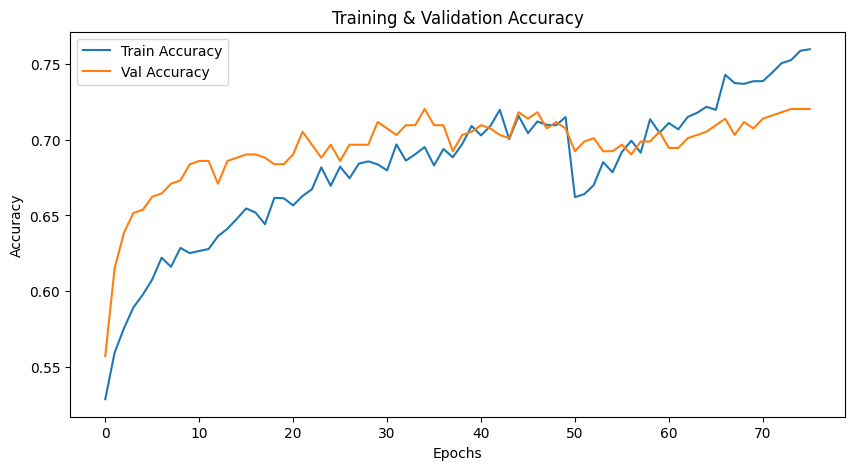

15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 952ms/step
              precision    recall  f1-score   support

    negative       0.72      0.74      0.73       235
    positive       0.73      0.70      0.71       230

    accuracy                           0.72       465
   macro avg       0.72      0.72      0.72       465
weighted avg       0.72      0.72      0.72       465



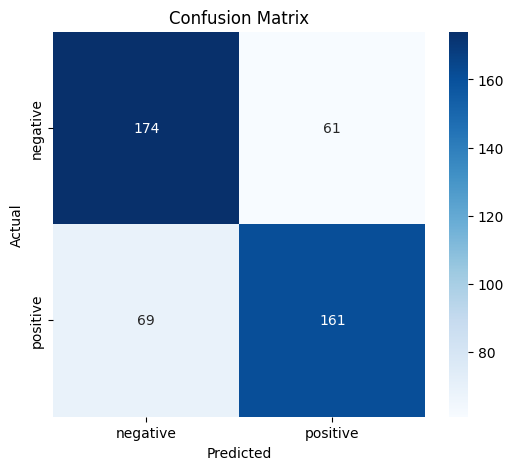

In [ ]:
# ==========================
# Plot Training Curves
# ==========================
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()

# ==========================
# Classification Report
# ==========================
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds), axis=1)
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()